In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter

# Gradient Descent: Batch Variants

Up until now, we have only looked at one concrete instance or variant of Gradient Descent.

It followed the rather simple procedure of updating the current parameters by subtracting the computed gradient for the respective parameter, multiplied by a certain learning rate.

We have expressed this update step for a parameter vector $\mathbf{w}$ as

$$
\mathbf{w}_{n+1} = \mathbf{w}_n - \eta \nabla_{\mathbf{w}} L
= \mathbf{w}_n - \eta \frac{\partial L}{\partial \mathbf{w}}
$$

Consequently, we have updated every parameter (of which we had a scalar intercept $b$ and a parameter vector $\mathbf{w}$ of size $m$) according to this update step after every iteration using the entirety of the training data of size $n$:

* compute the prediction $\hat{y}$ for all training rows, either with $\hat{y} = \mathbf{Xw}+b$ for Linear Regression or $\hat{y} = \sigma(\mathbf{Xw}+b)$ for Logistic Regression.
* compute the gradient $\nabla_{\mathbf{w}} L$ using all training rows
* compute the gradient $\nabla_b L$ using all training rows
* update $\mathbf{w}$ and $b$ according to the Gradient Descent update step

This procedure of using the entirety of the given training data for each parameter update is called Batch Gradient Descent, or BGD for short.

However, there are two other common variants of Gradient Descent:

**1) Stochastic Gradient Descent**

Stochastic Gradient Descent, or SGD for short, does not use the entire dataset for every parameter update. Instead, the parameters are updated based on only one randomly selected training sample at a time.

However, every row in the data is still used for an update within each epoch. Therefore, we need to adapt our way of looking at the loop of Gradient Descent.

Up until now, we had a singular loop, defined by the argument `max_iters`, that controlled how many times we wanted to update our parameters.

As we always used the full dataset in BGD, we did not have to distinguish between iterations and epochs. Each iteration used the complete dataset and therefore also corresponded to one complete pass through the training data.

With SGD, however, we perform multiple parameter updates within one complete pass through the dataset. Therefore, we introduce the concept of epochs.

An epoch represents one complete pass through the entire training dataset. Within each epoch, the dataset is typically shuffled and the samples are then processed one at a time. The nested loop therefore controls which individual samples are used for the parameter updates.

To conclude, for SGD, each parameter update is based on exactly one training sample, but this update is repeated for every training sample within one epoch.

For instance, with $5$ epochs and a dataset containing $2$ rows:

* epoch 1

  * nested loop iteration 1

    * select the first randomly ordered sample
    * compute $\hat{y}$ only for that sample
    * compute the gradient $\nabla_b L$ and $\nabla_{\mathbf{w}} L$ using only that sample
    * update $\mathbf{w}$ and $b$ according to the Gradient Descent update step
  * nested loop iteration 2

    * select the second sample
    * compute $\hat{y}$ only for that sample
    * compute the gradient $\nabla_b L$ and $\nabla_{\mathbf{w}} L$ using only that sample
    * update $\mathbf{w}$ and $b$ according to the Gradient Descent update step

* epoch 2

  * repeat the same procedure

* $\vdots$

* epoch 5

  * repeat the same procedure

Thus, with SGD, $n$ training samples result in $n$ parameter updates per epoch, compared to only one parameter update per epoch with Batch Gradient Descent.

**2) Mini-Batch Gradient Descent**  

Mini-Batch Gradient Descent, or MBGD for short, operates under the same underlying optimization framework as its counterparts, with a key modification: rather than calculating gradients using a single randomly selected instance per iteration (as in SGD), MBGD evaluates a subset of $k$ observations, introducing the hyperparameter batch size ($k$, where $1 < k < n$). 

While standard Batch Gradient Descent (BGD) computes updates across the entire dataset ($k = n$), MBGD utilizes a fraction of the data per iteration, most commonly powers of two such as 32, 64, 128 or 256. Consequently, processing a sample size of $k$ yields $\frac{n}{k}$ parameter updates per epoch, for $k$ training samples per iteration.

### Methodological Summary

The distinction between BGD, SGD and MBGD lies entirely in the choice of batch size $k$. The table below summarizes the trade-offs in batch size and update frequency per epoch across all three variants:

| Variant | Batch Size ($k$) | Parameter Updates per Epoch |
| :--- | :--- | :--- |
| **Batch Gradient Descent (BGD)** | $n$ | $\frac{n}{n} = 1$ |
| **Stochastic Gradient Descent (SGD)** | $1$ | $\frac{n}{1} = n$ |
| **Mini-Batch Gradient Descent (MBGD)** | $k$ (where $1 < k < n$) | $\frac{n}{k}$ |


In [1]:
%run src/gradient_descent_batch_variants.py

### Comparison

Lets revist a modified Regression problem. We will try to find optimal parameter values for the data below.

Here, the optimal parameter values are $w = 1.956$ and $b = 0.275$.

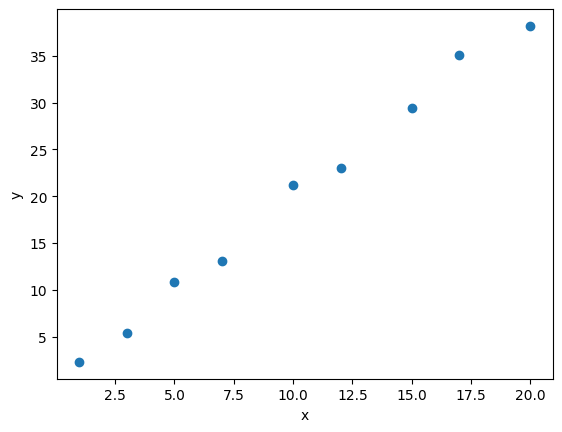

In [152]:
data = pd.DataFrame({
    "x": [1, 3, 5, 7, 10, 12, 15, 17, 20],
    "y": [2.3, 5.4, 10.8, 13.1, 21.2, 23.0, 29.4, 35.1, 38.2]
})

X = data[["x"]]
y = data["y"]

plt.scatter(X, y)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

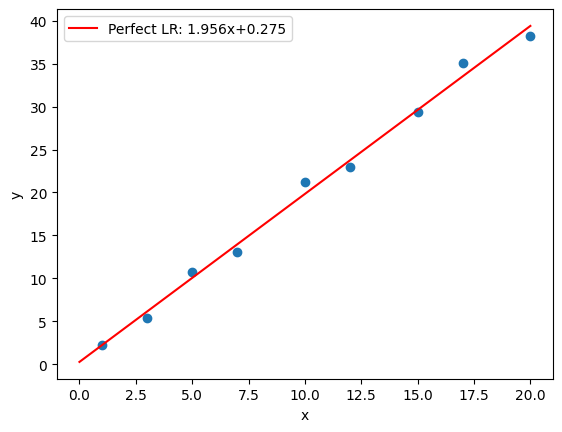

In [119]:
plt.scatter(X, y)
x_values = np.linspace(0, 20, 40)
plt.plot(x_values, 1.95584795*x_values + 0.27485380116952923, color="red", label="Perfect LR: 1.956x+0.275")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [153]:
lr_bgd = LinearRegression()
lr_bgd.fit(X, y, batch_method="batch", epochs=15)

lr_sgd = LinearRegression()
lr_sgd.fit(X, y, batch_method="stochastic", epochs=15)

lr_mbgd = LinearRegression()
lr_mbgd.fit(X, y, batch_method="mini_batch", epochs=15, batch_size=4)

The plot below illustrates the updates in the parameter value $w$.

The horizontal red line indicates the optimal value of $w$.

We can observe that all three variants converge towards the optimum. However, SGD exhibits substantially more noise during convergence and requires considerably more parameter updates than the other two variants.

MBGD produces a less noisy trajectory and requires more update steps than BGD, but fewer than SGD.

BGD converges towards the optimal value along a smooth trajectory and requires the fewest parameter updates.


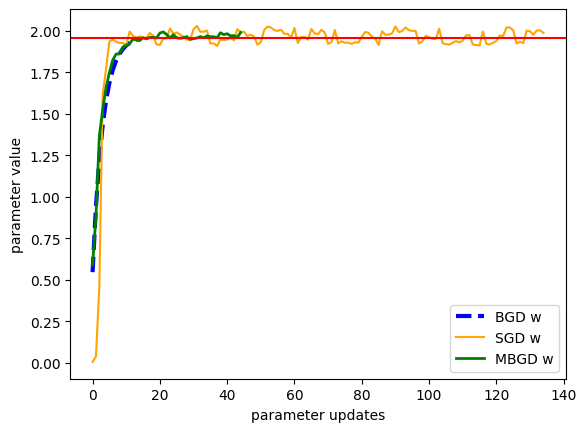

In [121]:
plt.plot(lr_bgd.w_hist, label="BGD w", linewidth=3, linestyle="--", color="blue")
plt.plot(lr_sgd.w_hist, label="SGD w", color="orange")
plt.plot(lr_mbgd.w_hist, label="MBGD w", linewidth=2, color="green")

plt.axhline(1.955, color="red")

plt.xlabel("parameter updates")
plt.ylabel("parameter value")

plt.legend()
plt.show()

In a more compact tabular view, both BGD and MBGD achieve parameter values for $w$ that are very close to the optimal value. 

However, both variants exhibit a more considerable error for the intercept $b$. 

SGD shows the largest deviation from the optimal values.


In [154]:
parameter_df = pd.DataFrame({
    "GD variant": ["Optimal", "BGD", "SGD", "MBGD"],
    "w": [1.95584795, lr_bgd.coefs_[0], lr_sgd.coefs_[0], lr_mbgd.coefs_[0]],
    "b": [0.27485380116952923, lr_bgd.intercept_, lr_sgd.intercept_, lr_mbgd.intercept_],
})
parameter_df

,GD variant,w,b
0,Optimal,1.955848,0.274854
1,BGD,1.950352,0.142698
2,SGD,1.923698,0.157052
3,MBGD,1.950996,0.143193


Nevertheless, all subsequent lines of form $wx+b$ remain very close to each other when considered from a broader perspective.

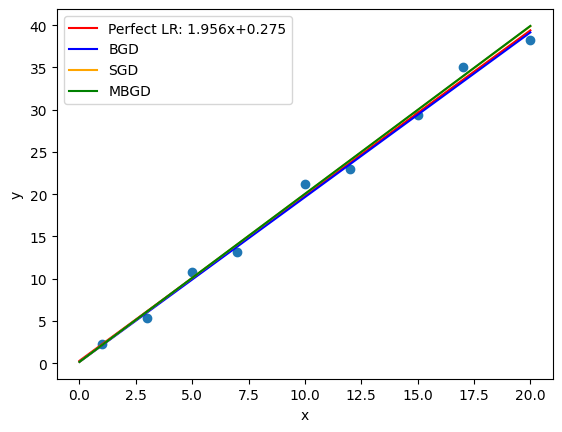

In [128]:
plt.scatter(X, y)
x_values = np.linspace(0, 20, 40)
plt.plot(x_values, 1.95584795*x_values + 0.27485380116952923, color="red", label="Perfect LR: 1.956x+0.275")

plt.plot(x_values, lr_bgd.coefs_[0]*x_values + lr_bgd.intercept_, color="blue", label="BGD")
plt.plot(x_values, lr_sgd.coefs_[0]*x_values + lr_sgd.intercept_, color="orange", label="SGD")
plt.plot(x_values, lr_mbgd.coefs_[0]*x_values + lr_mbgd.intercept_, color="green", label="MBGD")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

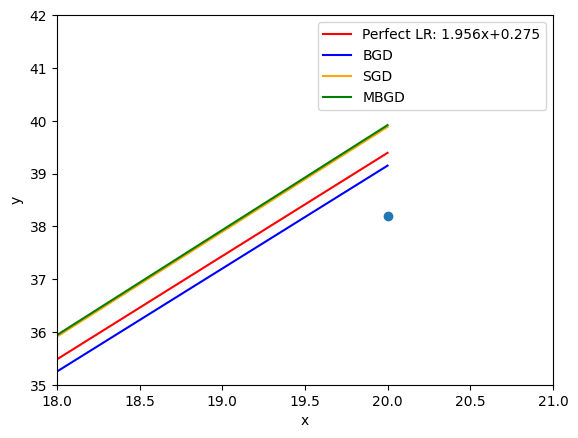

In [130]:
plt.scatter(X, y)
x_values = np.linspace(0, 20, 40)
plt.plot(x_values, 1.95584795*x_values + 0.27485380116952923, color="red", label="Perfect LR: 1.956x+0.275")

plt.plot(x_values, lr_bgd.coefs_[0]*x_values + lr_bgd.intercept_, color="blue", label="BGD")
plt.plot(x_values, lr_sgd.coefs_[0]*x_values + lr_sgd.intercept_, color="orange", label="SGD")
plt.plot(x_values, lr_mbgd.coefs_[0]*x_values + lr_mbgd.intercept_, color="green", label="MBGD")

plt.xlim(18, 21)
plt.ylim(35, 42)

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Lastly, let's observe the loss.

Again, BGD shows a smooth trajectory without noise, steadily decreasing towards 0.

MBGD shows some noise but ultimately comes very close to the trajectory of BGD.

Finally, SGD exhibits the most noise of all three variants.

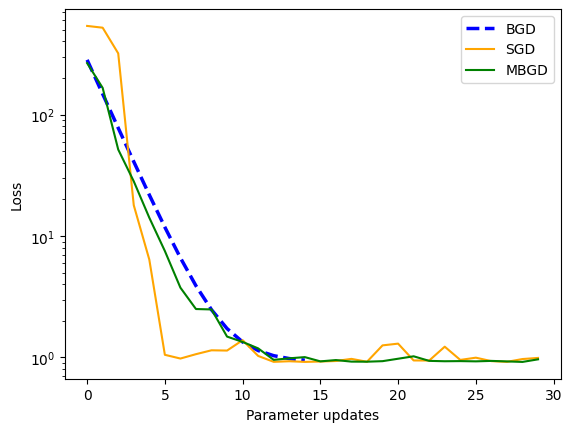

In [137]:
max_updates = 30

plt.plot(lr_bgd.losses_[:max_updates], label="BGD", color="blue", linewidth=2.5, linestyle="--")
plt.plot(lr_sgd.losses_[:max_updates], label="SGD", color="orange")
plt.plot(lr_mbgd.losses_[:max_updates], label="MBGD", color="green")

plt.yscale("log")
plt.xlabel("Parameter updates")
plt.ylabel("Loss")
plt.legend()
plt.show()

### More Complex Data

Let's consider more complex data. We'll revisit the Titanic dataset and use Logistic Regression to predict whether a passenger survived or died.

The dataset contains $714$ rows and $4$ features.

In [157]:
data = pd.read_csv("../2_machine_learning/data/titanic_dataset.csv")

data["Sex"] = data["Sex"].apply(lambda x: 1 if x == "male" else 0)
data = data.drop(columns=["PassengerId", "Name", "SibSp", "Parch", "Ticket", "Cabin", "Embarked"])
data = data[~data["Age"].isna()]

X = data.drop(columns=["Survived"])
y = data["Survived"]

print(f"n_samples: {X.shape[0]} | m_features: {X.shape[1]}")

n_samples: 714 | m_features: 4


For $1000$ epochs, BGD finished fastest on this machine, requiring only $0.1s$.

MBGD required $0.6s$, whereas SGD took $34.8s$ to converge to its final parameters within the given number of epochs.

The substantial difference in runtime is primarily explained by the number of parameter updates performed by each variant. BGD performs one update per epoch, while MBGD performs multiple updates per epoch and SGD performs one update for every training sample.

In [145]:
start_t = perf_counter()
lr_bgd = LogisticRegression()
lr_bgd.fit(X, y, batch_method="batch", epochs=1_000)
print(f"BGD: {perf_counter() - start_t:.3f}s")

start_t = perf_counter()
lr_sgd = LogisticRegression()
lr_sgd.fit(X, y, batch_method="stochastic", epochs=1_000)
print(f"SGD: {perf_counter() - start_t:.3f}s")

start_t = perf_counter()
lr_mbgd = LogisticRegression()
lr_mbgd.fit(X, y, batch_method="mini_batch", epochs=1_000, batch_size=64)
print(f"MBGD: {perf_counter() - start_t:.3f}s")

BGD: 0.106s
SGD: 34.787s
MBGD: 0.602s


Lastly, we can compare the final loss achieved by each variant.

BGD achieves the lowest loss of $0.604$ after only $1,000$ parameter updates. MBGD reaches a slightly higher loss of $0.649$ after $16,000$ updates, while SGD achieves the highest loss of $0.801$ despite performing $714,000$ parameter updates.

This illustrates that a higher number of parameter updates does not necessarily result in a lower loss. In this experiment, BGD reaches the lowest final loss with substantially fewer parameter updates than both MBGD and SGD.

In [149]:
parameter_df = pd.DataFrame({
    "GD variant": ["BGD", "SGD", "MBGD"],
    "Parameter Updates": [1000, 1000*X.shape[0], int(1000 * np.ceil(1000/64))],
    "Loss": [lr_bgd.losses_[-1], lr_sgd.losses_[-1], lr_mbgd.losses_[-1]],
})
parameter_df

,GD variant,Parameter Updates,Loss
0,BGD,1000,0.604372
1,SGD,714000,0.801119
2,MBGD,16000,0.648913


### Final Comparison

The following table summarizes the main differences between the three Gradient Descent variants considered.

| **Property**          | **BGD**                | **MBGD**            | **SGD**            |
| --------------------- | ---------------------- | ------------------- | ------------------ |
| **Gradient estimate** | Exact                  | Approximate         | Approximate |
| **Batch size**        | $n$                    | $1 < k < n$         | $1$                |
| **Updates per epoch** | $1$                    | $\lceil \frac{n}{k} \rceil$ | $n$                |
| **Gradient noise**    | None                   | Moderate            | High               |
| **Loss trajectory**   | Smooth                 | Slightly noisy      | Highly noisy       |
| **Vectorization**     | Excellent              | Excellent           | Limited            |
| **Time per fit**      | Low  | Moderate            | High               |
| **Memory per update** | High                   | Moderate            | Low                |

While BGD performs well on the smaller examples considered here, it becomes increasingly impractical as the dataset size grows. 

Real-world machine learning datasets can contain millions of observations and potentially millions of parameters. Computing the gradient over the entire dataset for every parameter update can therefore become computationally expensive and require substantial memory.

MBGD provides a practical compromise by computing approximate gradients over smaller batches. This reduces the computational and memory requirements of each update while retaining the benefits of vectorized computation. Also, the moderate gradient noise can help MBGD "jump" out of small local minima or saddle points, whereas BGD, due to its smoothed trajectory, would be stuck.

Consequently, mini-batch gradient descent is the common default for training neural networks, whereas BGD can remain suitable for smaller problems.

Pure SGD, using a batch size of exactly one as in this experiment, is generally less common.